In [1]:
# =============================================================================
# Notebook 02 — Treino dos 4 modelos de Faturamento (v1.0)
# fat_internado, fat_ps, fat_ambulatorial, fat_externo
# =============================================================================

import os
import sys
import json
from pathlib import Path
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from dotenv import load_dotenv

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
import holidays
import requests

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

# Conexao
for p in [Path('../.env'), Path('C:/ml_workspace/.env')]:
    if p.exists():
        load_dotenv(p)
        break

conn = psycopg2.connect(
    host=os.getenv('DB_HOST'),
    port=os.getenv('DB_PORT', '5432'),
    database=os.getenv('DB_NAME'),
    user=os.getenv('DB_USER'),
    password=os.getenv('DB_PASSWORD'),
)
print(f"Python: {sys.version.split()[0]}  |  LightGBM: {lgb.__version__}")
print(f"Conectado ao PostgreSQL")

# Constantes globais
DATA_REMOCAO_CARDIO = pd.Timestamp('2026-01-21')
LAT, LON = -15.82, -48.11
MODELS_DIR = Path('C:/ml_workspace/models')
MODELS_DIR.mkdir(exist_ok=True)

# Splits temporais
CORTE_TREINO    = pd.Timestamp('2026-02-28')
CORTE_VALIDACAO = pd.Timestamp('2026-03-20')
# Teste: 2026-03-21 ate ultimo dia disponivel

print(f"Splits: treino ate {CORTE_TREINO.date()} | val ate {CORTE_VALIDACAO.date()} | teste depois")

Python: 3.11.9  |  LightGBM: 4.5.0
Conectado ao PostgreSQL
Splits: treino ate 2026-02-28 | val ate 2026-03-20 | teste depois


In [2]:
# =============================================================================
# Carrega vw_faturamento_diario_tipo e separa em 4 DataFrames
# =============================================================================

df_longo = pd.read_sql("""
    SELECT *
    FROM public.vw_faturamento_diario_tipo
    ORDER BY data, tipo_atendimento
""", conn, parse_dates=['data'])

SEGMENTOS = {
    'internado':     'Internado',
    'ps':            'Pronto socorro',
    'ambulatorial':  'Atendimento Ambulatorial',
    'externo':       'Externo',
}

dfs = {}
for codigo, nome in SEGMENTOS.items():
    d = df_longo[df_longo['tipo_atendimento'] == nome].copy()
    d = d.set_index('data').sort_index()
    datas = pd.date_range(df_longo['data'].min(), df_longo['data'].max(), freq='D')
    d = d.reindex(datas)
    d.index.name = 'data'
    cols_num = d.select_dtypes(include='number').columns
    d[cols_num] = d[cols_num].fillna(0)
    d['tipo_atendimento'] = nome
    dfs[codigo] = d
    print(f"{codigo:>14}: {len(d)} dias | media R$ {d['vl_total'].mean():>11,.0f}/dia | "
          f"zeros: {(d['vl_total']==0).sum()}")

     internado: 835 dias | media R$     286,455/dia | zeros: 0
            ps: 835 dias | media R$      98,962/dia | zeros: 0
  ambulatorial: 835 dias | media R$      14,940/dia | zeros: 154
       externo: 835 dias | media R$      15,306/dia | zeros: 2


In [3]:
# =============================================================================
# Carrega clima do Parquet existente e atualiza com Open-Meteo se necessario
# =============================================================================

CLIMA_PATH = Path('C:/ml_workspace/data/clima_ceilandia.parquet')
clima_existente = pd.read_parquet(CLIMA_PATH)
print(f"Clima existente: {clima_existente.index.min().date()} -> {clima_existente.index.max().date()} ({len(clima_existente)} dias)")

DAILY_VARS = [
    'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
    'precipitation_sum', 'rain_sum', 'precipitation_hours',
    'wind_speed_10m_max', 'relative_humidity_2m_mean',
]
RENAME = {
    'temperature_2m_max': 'temp_max', 'temperature_2m_min': 'temp_min',
    'temperature_2m_mean': 'temp_media', 'precipitation_sum': 'precipitacao_mm',
    'rain_sum': 'chuva_mm', 'precipitation_hours': 'horas_chuva',
    'wind_speed_10m_max': 'vento_max', 'relative_humidity_2m_mean': 'umidade_media',
}

ultima_no_clima = clima_existente.index.max().date()
hoje = datetime.now().date()
fim_target = hoje + timedelta(days=10)  # cobre futuro pra inferencia

if ultima_no_clima < hoje - timedelta(days=1):
    print(f"Atualizando clima de {ultima_no_clima + timedelta(days=1)} ate {fim_target}...")
    inicio_novo = ultima_no_clima + timedelta(days=1)
    fim_hist = hoje - timedelta(days=1)
    novos_frames = []
    if inicio_novo <= fim_hist:
        r = requests.get('https://archive-api.open-meteo.com/v1/archive', params={
            'latitude': LAT, 'longitude': LON,
            'start_date': inicio_novo.strftime('%Y-%m-%d'),
            'end_date': fim_hist.strftime('%Y-%m-%d'),
            'daily': ','.join(DAILY_VARS), 'timezone': 'America/Sao_Paulo'
        }, timeout=60)
        r.raise_for_status()
        df_h = pd.DataFrame(r.json()['daily'])
        novos_frames.append(df_h)
    if fim_target >= hoje:
        r = requests.get('https://api.open-meteo.com/v1/forecast', params={
            'latitude': LAT, 'longitude': LON,
            'start_date': hoje.strftime('%Y-%m-%d'),
            'end_date': fim_target.strftime('%Y-%m-%d'),
            'daily': ','.join(DAILY_VARS), 'timezone': 'America/Sao_Paulo'
        }, timeout=60)
        r.raise_for_status()
        df_f = pd.DataFrame(r.json()['daily'])
        novos_frames.append(df_f)
    novo = pd.concat(novos_frames, ignore_index=True)
    novo['time'] = pd.to_datetime(novo['time'])
    novo = novo.set_index('time').rename(columns=RENAME)
    novo.index.name = 'data'
    clima = pd.concat([clima_existente, novo])
    clima = clima[~clima.index.duplicated(keep='last')]
    clima.to_parquet(CLIMA_PATH)
    print(f"Clima atualizado: {clima.index.min().date()} -> {clima.index.max().date()} ({len(clima)} dias)")
else:
    clima = clima_existente

print(f"Clima final em uso: {len(clima)} dias")

Clima existente: 2023-07-14 -> 2026-04-08 (1000 dias)
Atualizando clima de 2026-04-09 ate 2026-04-24...
Clima atualizado: 2023-07-14 -> 2026-04-24 (1016 dias)
Clima final em uso: 1016 dias


In [4]:
# =============================================================================
# Funcoes de feature engineering
# Toda transformacao usada aqui DEVE estar tambem no features_faturamento.py
# (que vai pro worker em producao)
# =============================================================================

def adicionar_calendario(df):
    df = df.copy()
    df['ano'] = df.index.year
    df['mes'] = df.index.month
    df['dia_mes'] = df.index.day
    df['dia_semana'] = df.index.dayofweek
    df['dia_ano'] = df.index.dayofyear
    df['semana_ano'] = df.index.isocalendar().week.astype(int).values
    df['trimestre'] = df.index.quarter
    df['is_segunda'] = (df['dia_semana'] == 0).astype(int)
    df['is_fim_semana'] = (df['dia_semana'] >= 5).astype(int)
    df['is_primeira_quinzena'] = (df['dia_mes'] <= 15).astype(int)
    df['dia_semana_sin'] = np.sin(2 * np.pi * df['dia_semana'] / 7)
    df['dia_semana_cos'] = np.cos(2 * np.pi * df['dia_semana'] / 7)
    df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12)
    df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12)
    return df


def adicionar_feriados(df):
    df = df.copy()
    anos = list(range(df.index.year.min(), df.index.year.max() + 1))
    feriados_br = holidays.Brazil(years=anos, subdiv='DF')
    feriado_set = set(feriados_br.keys())
    df['is_feriado'] = df.index.to_series().apply(lambda d: d.date() in feriados_br).astype(int)
    df['is_vespera_feriado'] = df.index.to_series().apply(
        lambda d: (d.date() + timedelta(days=1)) in feriado_set).astype(int)
    df['is_pos_feriado'] = df.index.to_series().apply(
        lambda d: (d.date() - timedelta(days=1)) in feriado_set).astype(int)
    return df


def adicionar_flag_cardiologia_removida(df):
    df = df.copy()
    df['flag_cardiologia_removida'] = (df.index >= DATA_REMOCAO_CARDIO).astype(int)
    return df


def adicionar_lags(df, coluna, prefixo, lags, mm_janelas):
    df = df.copy()
    for lag in lags:
        df[f'{prefixo}_lag_{lag}d'] = df[coluna].shift(lag)
    for j in mm_janelas:
        df[f'{prefixo}_mm_{j}d'] = df[coluna].shift(1).rolling(j).mean()
    return df


def juntar_clima(df, clima):
    return df.join(clima.reindex(df.index), how='left')


print("Funcoes de feature engineering definidas.")

Funcoes de feature engineering definidas.


In [5]:
# =============================================================================
# Features ESPECIFICAS por modelo, baseadas no EDA
# (calendario + feriados + flag_cardio + clima sao compartilhadas)
# =============================================================================

FEATURES_BASE = [
    # Calendario (14)
    'ano', 'mes', 'dia_mes', 'dia_semana', 'dia_ano', 'semana_ano', 'trimestre',
    'is_segunda', 'is_fim_semana', 'is_primeira_quinzena',
    'dia_semana_sin', 'dia_semana_cos', 'mes_sin', 'mes_cos',
    # Feriados (3)
    'is_feriado', 'is_vespera_feriado', 'is_pos_feriado',
    # Flag estrutural (1)
    'flag_cardiologia_removida',
    # Clima (8)
    'temp_max', 'temp_min', 'temp_media',
    'precipitacao_mm', 'chuva_mm', 'horas_chuva',
    'umidade_media', 'vento_max',
]
print(f"FEATURES_BASE: {len(FEATURES_BASE)} features")


# Modelo INTERNADO: ACF planissima nos lags do alvo,
# mas vl_uti tem r=0.884. Inclui muitos lags de UTI/CC/Hemodinamica.
FEATURES_INTERNADO_EXTRA = [
    'vl_uti_lag_1d', 'vl_uti_lag_7d', 'vl_uti_lag_14d',
    'vl_uti_mm_7d', 'vl_uti_mm_14d',
    'qt_atend_uti_lag_1d', 'qt_atend_uti_lag_7d', 'qt_atend_uti_mm_7d',
    'vl_centro_cirurgico_lag_1d', 'vl_centro_cirurgico_lag_7d', 'vl_centro_cirurgico_mm_7d',
    'vl_hemodinamica_lag_7d', 'vl_hemodinamica_mm_7d',
    'vl_total_lag_1d', 'vl_total_lag_7d', 'vl_total_mm_7d',
]

# Modelo PS: ACF muito boa nos multiplos de 7. Lags fortes do proprio alvo.
FEATURES_PS_EXTRA = [
    'vl_total_lag_1d', 'vl_total_lag_2d', 'vl_total_lag_7d', 'vl_total_lag_14d', 'vl_total_lag_21d',
    'vl_total_mm_7d', 'vl_total_mm_14d', 'vl_total_mm_28d',
    'qt_atendimentos_lag_1d', 'qt_atendimentos_lag_7d', 'qt_atendimentos_mm_7d',
]

# Modelo AMBULATORIAL: filtra dias uteis, lags importantes em multiplos de 7.
FEATURES_AMB_EXTRA = [
    'vl_total_lag_7d', 'vl_total_lag_14d',
    'vl_total_mm_7d',
    'qt_atendimentos_lag_7d',
]

# Modelo EXTERNO: ACF mostra pico em lag 7 e 14. Mais simples.
FEATURES_EXTERNO_EXTRA = [
    'vl_total_lag_1d', 'vl_total_lag_7d', 'vl_total_lag_14d',
    'vl_total_mm_7d',
]

CONFIG_MODELOS = {
    'internado':    {'features': FEATURES_BASE + FEATURES_INTERNADO_EXTRA, 'usa_log': True,  'filtro_dias_uteis': False},
    'ps':           {'features': FEATURES_BASE + FEATURES_PS_EXTRA,        'usa_log': True,  'filtro_dias_uteis': False},
    'ambulatorial': {'features': FEATURES_BASE + FEATURES_AMB_EXTRA,       'usa_log': True,  'filtro_dias_uteis': True},
    'externo':      {'features': FEATURES_BASE + FEATURES_EXTERNO_EXTRA,   'usa_log': False, 'filtro_dias_uteis': False},
}

for cod, cfg in CONFIG_MODELOS.items():
    print(f"  {cod:>14}: {len(cfg['features']):>2} features  | log={cfg['usa_log']}  | filtra_dias_uteis={cfg['filtro_dias_uteis']}")

FEATURES_BASE: 26 features
       internado: 42 features  | log=True  | filtra_dias_uteis=False
              ps: 37 features  | log=True  | filtra_dias_uteis=False
    ambulatorial: 30 features  | log=True  | filtra_dias_uteis=True
         externo: 30 features  | log=False  | filtra_dias_uteis=False


In [6]:
# =============================================================================
# Aplica feature engineering em cada um dos 4 DataFrames
# =============================================================================

dfs_features = {}

for codigo, d in dfs.items():
    cfg = CONFIG_MODELOS[codigo]
    df = d.copy()

    # Base compartilhada
    df = adicionar_calendario(df)
    df = adicionar_feriados(df)
    df = adicionar_flag_cardiologia_removida(df)

    # Lags do proprio alvo
    df = adicionar_lags(df, 'vl_total', 'vl_total',
                        lags=[1, 2, 7, 14, 21], mm_janelas=[7, 14, 28])
    df = adicionar_lags(df, 'qt_atendimentos', 'qt_atendimentos',
                        lags=[1, 7], mm_janelas=[7])

    # Features especificas pro Internado: lags de UTI e Centro Cirurgico e Hemodinamica
    if codigo == 'internado':
        df = adicionar_lags(df, 'vl_uti', 'vl_uti', lags=[1, 7, 14], mm_janelas=[7, 14])
        df = adicionar_lags(df, 'qt_atend_uti', 'qt_atend_uti', lags=[1, 7], mm_janelas=[7])
        df = adicionar_lags(df, 'vl_centro_cirurgico', 'vl_centro_cirurgico', lags=[1, 7], mm_janelas=[7])
        df = adicionar_lags(df, 'vl_hemodinamica', 'vl_hemodinamica', lags=[7], mm_janelas=[7])

    # Clima
    df = juntar_clima(df, clima)

    # Filtro de dias uteis pro Ambulatorial
    if cfg['filtro_dias_uteis']:
        antes = len(df)
        df = df[df['vl_total'] > 0].copy()
        print(f"  {codigo}: filtrou dias uteis {antes} -> {len(df)} ({antes - len(df)} dias zerados removidos)")

    dfs_features[codigo] = df
    print(f"  {codigo:>14}: shape final {df.shape}")

       internado: shape final (835, 75)
              ps: shape final (835, 62)
  ambulatorial: filtrou dias uteis 835 -> 681 (154 dias zerados removidos)
    ambulatorial: shape final (681, 62)
         externo: shape final (835, 62)


In [7]:
# =============================================================================
# Funcao reutilizavel: treina um modelo, retorna model + metricas + features importance
# =============================================================================

PARAMS_BASE = {
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.85,
    'bagging_fraction': 0.85,
    'bagging_freq': 5,
    'min_child_samples': 10,
    'verbose': -1,
    'seed': 42,
    'n_jobs': -1,
}


def treinar_modelo_segmento(codigo, df_features, cfg, params=None):
    """Treina LightGBM, com ou sem log1p no alvo."""
    if params is None:
        params = PARAMS_BASE.copy()

    features = cfg['features']

    # Garante que tem todas as features (algumas podem nao existir se o segmento nao gera)
    features_existentes = [f for f in features if f in df_features.columns]
    faltantes = set(features) - set(features_existentes)
    if faltantes:
        print(f"  AVISO: features ausentes no {codigo}: {faltantes}")
    features = features_existentes

    # Drop linhas com NaN nas features (causadas por lags no comeco da serie)
    df_clean = df_features.dropna(subset=features + ['vl_total']).copy()

    # Splits temporais
    treino = df_clean[df_clean.index <= CORTE_TREINO]
    valid  = df_clean[(df_clean.index > CORTE_TREINO) & (df_clean.index <= CORTE_VALIDACAO)]
    teste  = df_clean[df_clean.index > CORTE_VALIDACAO]

    # Alvo (com ou sem log)
    if cfg['usa_log']:
        y_treino_t = np.log1p(treino['vl_total'])
        y_valid_t = np.log1p(valid['vl_total'])
    else:
        y_treino_t = treino['vl_total']
        y_valid_t = valid['vl_total']

    X_treino, X_valid, X_teste = treino[features], valid[features], teste[features]

    # Treina
    model = lgb.train(
        params,
        lgb.Dataset(X_treino, label=y_treino_t),
        num_boost_round=2000,
        valid_sets=[lgb.Dataset(X_treino, label=y_treino_t),
                    lgb.Dataset(X_valid, label=y_valid_t)],
        valid_names=['treino', 'valid'],
        callbacks=[lgb.early_stopping(80), lgb.log_evaluation(0)],
    )

    # Prediz no teste e desfaz transform
    pred_teste_raw = model.predict(X_teste, num_iteration=model.best_iteration)
    if cfg['usa_log']:
        pred_teste = np.expm1(pred_teste_raw)
    else:
        pred_teste = pred_teste_raw

    pred_teste = np.maximum(pred_teste, 0)  # nao permite previsao negativa

    real_teste = teste['vl_total'].values
    mae = mean_absolute_error(real_teste, pred_teste)
    rmse = np.sqrt(mean_squared_error(real_teste, pred_teste))
    mape = np.mean(np.abs((real_teste - pred_teste) / np.maximum(real_teste, 1))) * 100
    mae_mediano = np.median(np.abs(real_teste - pred_teste))

    # Baseline ingenuo: media dos ultimos 7d
    baseline_pred = treino['vl_total'].iloc[-7:].mean()
    mae_baseline = mean_absolute_error(real_teste, [baseline_pred] * len(real_teste))

    return {
        'model': model,
        'features': features,
        'mae': mae, 'rmse': rmse, 'mape': mape, 'mae_mediano': mae_mediano,
        'mae_baseline': mae_baseline,
        'ganho_pct': (mae_baseline - mae) / mae_baseline * 100,
        'n_treino': len(treino), 'n_valid': len(valid), 'n_teste': len(teste),
        'arvores': model.best_iteration,
        'pred_teste': pred_teste, 'real_teste': real_teste,
        'datas_teste': teste.index,
    }


print("Funcao treinar_modelo_segmento definida.")

Funcao treinar_modelo_segmento definida.


In [8]:
# =============================================================================
# fat_internado v1.0
# =============================================================================
print("=" * 70)
print("TREINANDO fat_internado v1.0")
print("=" * 70)

resultados = {}
resultados['internado'] = treinar_modelo_segmento(
    'internado', dfs_features['internado'], CONFIG_MODELOS['internado']
)

r = resultados['internado']
print(f"\n  Arvores: {r['arvores']}")
print(f"  Treino:  {r['n_treino']} dias  |  Valid: {r['n_valid']}  |  Teste: {r['n_teste']}")
print(f"  MAE teste:        R$ {r['mae']:>14,.2f}")
print(f"  MAE mediano:      R$ {r['mae_mediano']:>14,.2f}  (mais robusto a outliers)")
print(f"  MAPE teste:                {r['mape']:>5.1f}%")
print(f"  RMSE teste:       R$ {r['rmse']:>14,.2f}")
print(f"  Baseline (media): R$ {r['mae_baseline']:>14,.2f}")
print(f"  Ganho sobre baseline:     {r['ganho_pct']:+.1f}%")

TREINANDO fat_internado v1.0
Training until validation scores don't improve for 80 rounds
Early stopping, best iteration is:
[38]	treino's l1: 0.294862	valid's l1: 0.32327

  Arvores: 38
  Treino:  776 dias  |  Valid: 20  |  Teste: 25
  MAE teste:        R$     113,171.07
  MAE mediano:      R$      52,337.43  (mais robusto a outliers)
  MAPE teste:                742.5%
  RMSE teste:       R$     170,599.53
  Baseline (media): R$     126,980.46
  Ganho sobre baseline:     +10.9%


In [9]:
print("=" * 70)
print("TREINANDO fat_ps v1.0")
print("=" * 70)

resultados['ps'] = treinar_modelo_segmento(
    'ps', dfs_features['ps'], CONFIG_MODELOS['ps']
)

r = resultados['ps']
print(f"\n  Arvores: {r['arvores']}  |  Teste: {r['n_teste']} dias")
print(f"  MAE teste:        R$ {r['mae']:>12,.2f}  ({r['mape']:.1f}% MAPE)")
print(f"  Baseline (media): R$ {r['mae_baseline']:>12,.2f}")
print(f"  Ganho:                    {r['ganho_pct']:+.1f}%")

TREINANDO fat_ps v1.0
Training until validation scores don't improve for 80 rounds
Early stopping, best iteration is:
[69]	treino's l1: 0.0513825	valid's l1: 0.0773653

  Arvores: 69  |  Teste: 25 dias
  MAE teste:        R$    13,417.40  (38.3% MAPE)
  Baseline (media): R$    21,665.00
  Ganho:                    +38.1%


In [10]:
print("=" * 70)
print("TREINANDO fat_ambulatorial v1.0  (so dias uteis)")
print("=" * 70)

resultados['ambulatorial'] = treinar_modelo_segmento(
    'ambulatorial', dfs_features['ambulatorial'], CONFIG_MODELOS['ambulatorial']
)

r = resultados['ambulatorial']
print(f"\n  Arvores: {r['arvores']}  |  Teste: {r['n_teste']} dias")
print(f"  MAE teste:        R$ {r['mae']:>10,.2f}  ({r['mape']:.1f}% MAPE)")
print(f"  Baseline (media): R$ {r['mae_baseline']:>10,.2f}")
print(f"  Ganho:                    {r['ganho_pct']:+.1f}%")

TREINANDO fat_ambulatorial v1.0  (so dias uteis)
Training until validation scores don't improve for 80 rounds
Early stopping, best iteration is:
[60]	treino's l1: 0.216686	valid's l1: 0.328397

  Arvores: 60  |  Teste: 17 dias
  MAE teste:        R$  10,432.69  (217.5% MAPE)
  Baseline (media): R$  10,764.15
  Ganho:                    +3.1%


In [11]:
print("=" * 70)
print("TREINANDO fat_externo v1.0  (sem log)")
print("=" * 70)

resultados['externo'] = treinar_modelo_segmento(
    'externo', dfs_features['externo'], CONFIG_MODELOS['externo']
)

r = resultados['externo']
print(f"\n  Arvores: {r['arvores']}  |  Teste: {r['n_teste']} dias")
print(f"  MAE teste:        R$ {r['mae']:>10,.2f}  ({r['mape']:.1f}% MAPE)")
print(f"  Baseline (media): R$ {r['mae_baseline']:>10,.2f}")
print(f"  Ganho:                    {r['ganho_pct']:+.1f}%")

TREINANDO fat_externo v1.0  (sem log)
Training until validation scores don't improve for 80 rounds
Early stopping, best iteration is:
[45]	treino's l1: 2079.15	valid's l1: 3717.25

  Arvores: 45  |  Teste: 25 dias
  MAE teste:        R$   5,735.70  (102.8% MAPE)
  Baseline (media): R$   8,502.37
  Ganho:                    +32.5%


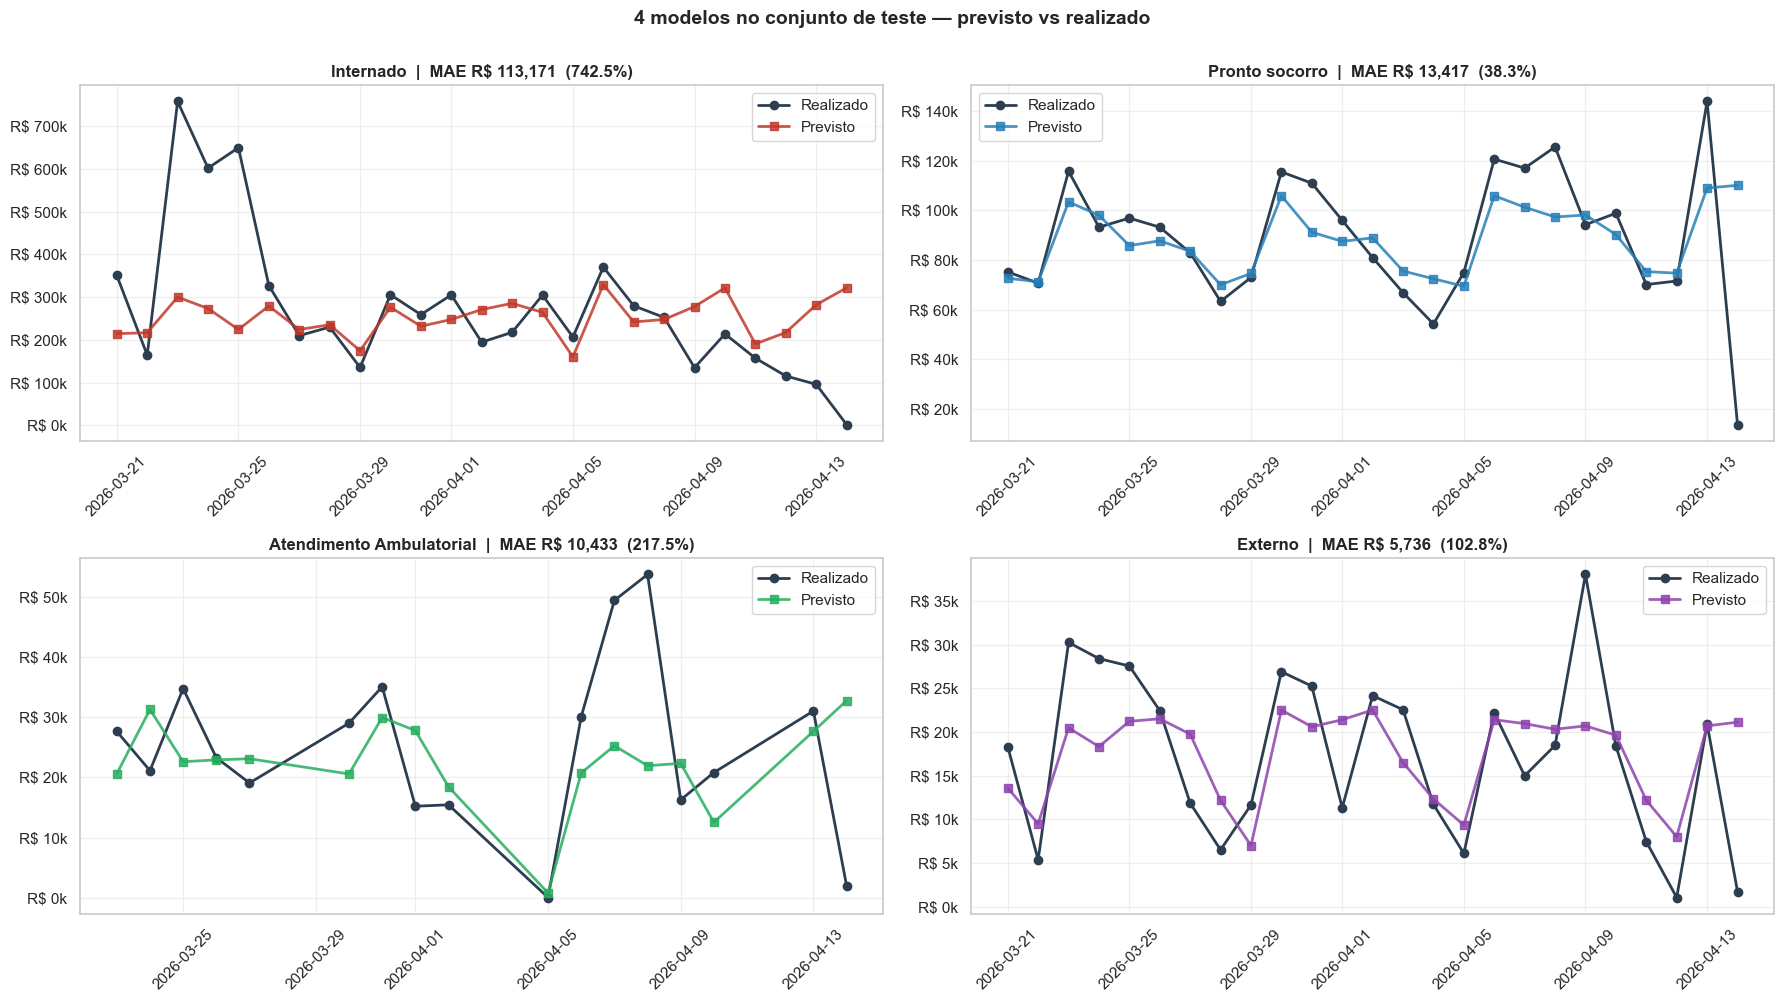

In [12]:
# =============================================================================
# Comparativo dos 4 modelos: previsto vs realizado no teste
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
cores = {'internado': '#c0392b', 'ps': '#2980b9',
         'ambulatorial': '#27ae60', 'externo': '#8e44ad'}

for ax, codigo in zip(axes.flatten(), resultados.keys()):
    r = resultados[codigo]
    ax.plot(r['datas_teste'], r['real_teste'], 'o-', color='#2c3e50', label='Realizado', linewidth=2)
    ax.plot(r['datas_teste'], r['pred_teste'], 's-', color=cores[codigo], label='Previsto', linewidth=2, alpha=0.85)

    titulo = f'{SEGMENTOS[codigo]}  |  MAE R$ {r["mae"]:,.0f}  ({r["mape"]:.1f}%)'
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(
        lambda x, _: f'R$ {x/1000:.0f}k'))
    ax.legend()
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('4 modelos no conjunto de teste — previsto vs realizado',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [18]:
# =============================================================================
# Soma dos 4 modelos = previsao do faturamento TOTAL do hospital
# Esta e a metrica headline pro painel
# =============================================================================

# Alinha os 4 resultados pelas mesmas datas
datas_teste_comuns = sorted(set.intersection(*[
    set(r['datas_teste']) for r in resultados.values()
]))

real_total = np.zeros(len(datas_teste_comuns))
pred_total = np.zeros(len(datas_teste_comuns))

for codigo, r in resultados.items():
    s_real = pd.Series(r['real_teste'], index=r['datas_teste'])
    s_pred = pd.Series(r['pred_teste'], index=r['datas_teste'])
    real_total += s_real.reindex(datas_teste_comuns).fillna(0).values
    pred_total += s_pred.reindex(datas_teste_comuns).fillna(0).values

mae_total = mean_absolute_error(real_total, pred_total)
mape_total = np.mean(np.abs((real_total - pred_total) / np.maximum(real_total, 1))) * 100
rmse_total = np.sqrt(mean_squared_error(real_total, pred_total))

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(datas_teste_comuns, real_total, 'o-', color='#2c3e50', label='Realizado', linewidth=2.5)
ax.plot(datas_teste_comuns, pred_total, 's-', color='#dc3545', label='Previsto (soma 4 modelos)', linewidth=2.5)
ax.fill_between(datas_teste_comuns, pred_total - mae_total, pred_total + mae_total,
                alpha=0.15, color='#dc3545', label=f'+- MAE')
ax.set_title(f'FATURAMENTO TOTAL DIARIO — Previsto vs Realizado no teste\n'
             f'MAE R$ {mae_total:,.2f}  |  MAPE {mape_total:.1f}%  |  RMSE R$ {rmse_total:,.2f}',
             fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(
    lambda x, _: f'R$ {x/1000:.0f}k'))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n=== TOTAL DO HOSPITAL (soma dos 4 modelos) ===")
print(f"  MAE:         R$ {mae_total:>14,.2f}")
print(f"  MAPE:               {mape_total:>5.1f}%")
print(f"  RMSE:        R$ {rmse_total:>14,.2f}")
print(f"  Media real:  R$ {real_total.mean():>14,.2f}/dia")
print(f"  Media prev:  R$ {pred_total.mean():>14,.2f}/dia")

ValueError: 
MAE R$ 157,438.35  |  MAPE 167.7%  |  RMSE R$ 223,727.34
     ^
ParseException: Expected end of text, found '$'  (at char 5), (line:1, col:6)

Error in callback <function _draw_all_if_interactive at 0x000001D23C7122A0> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
MAE R$ 157,438.35  |  MAPE 167.7%  |  RMSE R$ 223,727.34
     ^
ParseException: Expected end of text, found '$'  (at char 5), (line:1, col:6)

ValueError: 
MAE R$ 157,438.35  |  MAPE 167.7%  |  RMSE R$ 223,727.34
     ^
ParseException: Expected end of text, found '$'  (at char 5), (line:1, col:6)

<Figure size 1600x600 with 1 Axes>

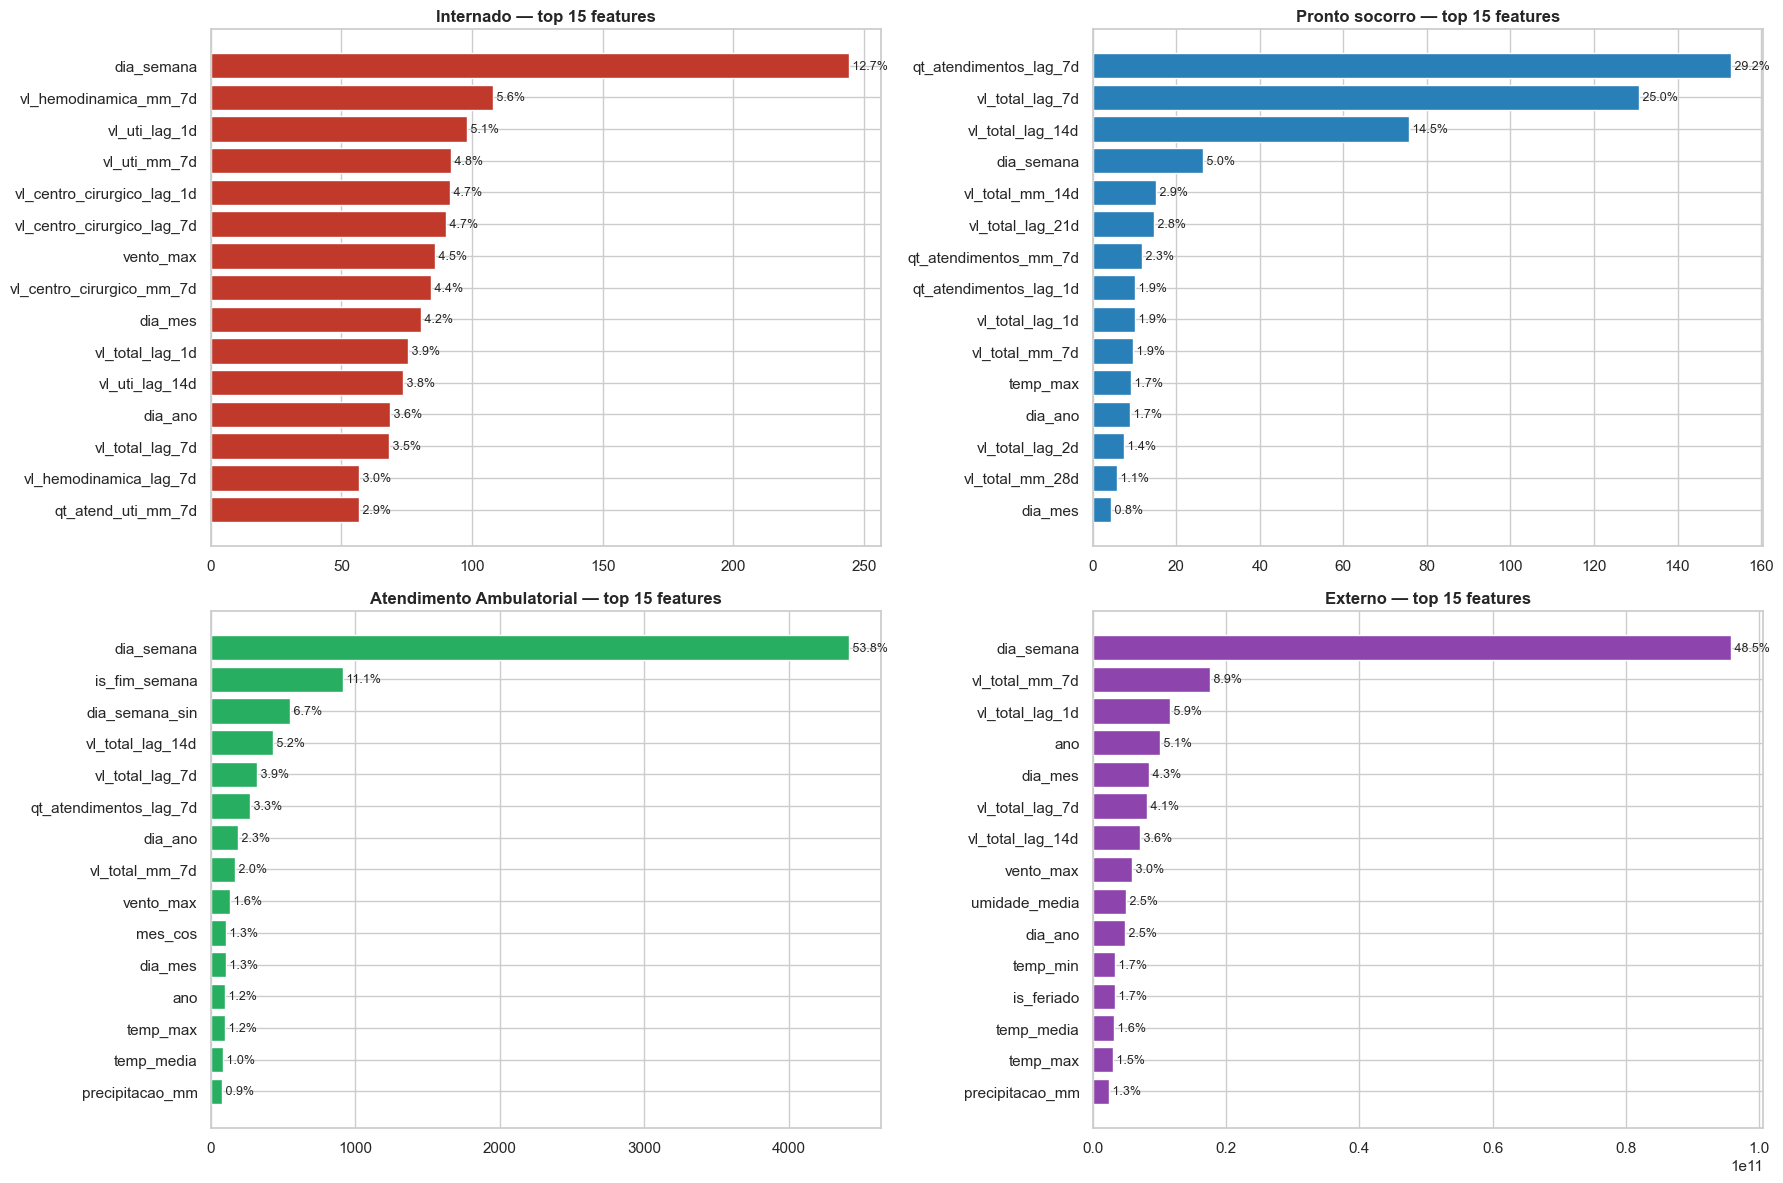

In [14]:
# =============================================================================
# Top features de cada modelo
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for ax, codigo in zip(axes.flatten(), resultados.keys()):
    r = resultados[codigo]
    imp = pd.DataFrame({
        'feature': r['features'],
        'importance': r['model'].feature_importance(importance_type='gain'),
    }).sort_values('importance', ascending=True).tail(15)
    total = imp['importance'].sum()
    imp['pct'] = imp['importance'] / r['model'].feature_importance(importance_type='gain').sum() * 100

    bars = ax.barh(imp['feature'], imp['importance'], color=cores[codigo])
    ax.set_title(f'{SEGMENTOS[codigo]} — top 15 features', fontsize=12, fontweight='bold')
    for bar, pct in zip(bars, imp['pct']):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                f' {pct:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [15]:
# =============================================================================
# Serializa modelos pro worker em producao
# =============================================================================

for codigo, r in resultados.items():
    cfg = CONFIG_MODELOS[codigo]
    nome_arq = f'fat_{codigo}_v1'

    # Salva o .pkl
    pkl_path = MODELS_DIR / f'{nome_arq}.pkl'
    joblib.dump(r['model'], pkl_path)

    # Salva o .json metadata
    meta = {
        'nome': f'fat_{codigo}',
        'versao': 'v1.0',
        'descricao': f'Modelo de faturamento para {SEGMENTOS[codigo]}',
        'data_treino': datetime.now().strftime('%Y-%m-%d %H:%M'),
        'algoritmo': 'LightGBM',
        'num_features': len(r['features']),
        'features': r['features'],
        'usa_log1p': cfg['usa_log'],
        'filtro_dias_uteis': cfg['filtro_dias_uteis'],
        'periodo_treino_inicio': '2024-01-01',
        'periodo_treino_fim':    CORTE_TREINO.strftime('%Y-%m-%d'),
        'periodo_validacao_inicio': (CORTE_TREINO + timedelta(days=1)).strftime('%Y-%m-%d'),
        'periodo_validacao_fim':    CORTE_VALIDACAO.strftime('%Y-%m-%d'),
        'periodo_teste_inicio': (CORTE_VALIDACAO + timedelta(days=1)).strftime('%Y-%m-%d'),
        'periodo_teste_fim':    str(max(r['datas_teste']).date()),
        'num_amostras_treino': r['n_treino'],
        'num_arvores': r['arvores'],
        'metricas': {
            'mae_teste':         round(float(r['mae']), 2),
            'mae_mediano_teste': round(float(r['mae_mediano']), 2),
            'mape_teste':        round(float(r['mape']), 2),
            'rmse_teste':        round(float(r['rmse']), 2),
            'mae_baseline':      round(float(r['mae_baseline']), 2),
            'ganho_sobre_baseline_pct': round(float(r['ganho_pct']), 1),
        },
        'hiperparametros': PARAMS_BASE,
        'observacoes': f'Segmento {SEGMENTOS[codigo]}. Inclui flag_cardiologia_removida.',
    }
    json_path = MODELS_DIR / f'{nome_arq}_meta.json'
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)

    print(f"  OK {pkl_path.name}  +  {json_path.name}")

print(f"\nTodos os artefatos salvos em {MODELS_DIR}")

  OK fat_internado_v1.pkl  +  fat_internado_v1_meta.json
  OK fat_ps_v1.pkl  +  fat_ps_v1_meta.json
  OK fat_ambulatorial_v1.pkl  +  fat_ambulatorial_v1_meta.json
  OK fat_externo_v1.pkl  +  fat_externo_v1_meta.json

Todos os artefatos salvos em C:\ml_workspace\models


In [16]:
# =============================================================================
# Gera SQL pronto pra rodar no PostgreSQL e registrar os 4 modelos
# =============================================================================

sql = "-- INSERT dos 4 modelos no ml_modelos_registry\n"
sql += "-- Gerado automaticamente pelo Notebook 02\n\n"

for codigo, r in resultados.items():
    cfg = CONFIG_MODELOS[codigo]
    sql += f"""
INSERT INTO public.ml_modelos_registry (
    nome_modelo, versao, descricao, categoria, algoritmo,
    caminho_pkl, caminho_metadata,
    periodo_treino_inicio, periodo_treino_fim, num_amostras_treino,
    mae_teste, mape_teste, rmse_teste,
    num_features, status, criado_por, observacoes
) VALUES (
    'fat_{codigo}', 'v1.0',
    '{SEGMENTOS[codigo]} - faturamento diario, log1p={cfg["usa_log"]}',
    'previsao_financeira', 'LightGBM',
    'C:/ml_workspace/models/fat_{codigo}_v1.pkl',
    'C:/ml_workspace/models/fat_{codigo}_v1_meta.json',
    '2024-01-01', '{CORTE_TREINO.strftime("%Y-%m-%d")}',
    {r['n_treino']},
    {r['mae']:.2f}, {r['mape']:.2f}, {r['rmse']:.2f},
    {len(r['features'])}, 'producao', 'lucas',
    'v1 inicial. MAE_baseline R$ {r["mae_baseline"]:.2f}, ganho {r["ganho_pct"]:.1f}%.'
);
"""

print(sql)

# Salva tambem em arquivo
with open('../models/04_registry_inserts.sql', 'w', encoding='utf-8') as f:
    f.write(sql)
print("\nSQL salvo em ../models/04_registry_inserts.sql")

-- INSERT dos 4 modelos no ml_modelos_registry
-- Gerado automaticamente pelo Notebook 02


INSERT INTO public.ml_modelos_registry (
    nome_modelo, versao, descricao, categoria, algoritmo,
    caminho_pkl, caminho_metadata,
    periodo_treino_inicio, periodo_treino_fim, num_amostras_treino,
    mae_teste, mape_teste, rmse_teste,
    num_features, status, criado_por, observacoes
) VALUES (
    'fat_internado', 'v1.0',
    'Internado - faturamento diario, log1p=True',
    'previsao_financeira', 'LightGBM',
    'C:/ml_workspace/models/fat_internado_v1.pkl',
    'C:/ml_workspace/models/fat_internado_v1_meta.json',
    '2024-01-01', '2026-02-28',
    776,
    113171.07, 742.49, 170599.53,
    42, 'producao', 'lucas',
    'v1 inicial. MAE_baseline R$ 126980.46, ganho 10.9%.'
);

INSERT INTO public.ml_modelos_registry (
    nome_modelo, versao, descricao, categoria, algoritmo,
    caminho_pkl, caminho_metadata,
    periodo_treino_inicio, periodo_treino_fim, num_amostras_treino,
    mae_test

In [17]:
# =============================================================================
# SUMARIO E PROXIMOS PASSOS
# =============================================================================

print("=" * 75)
print("RESUMO DO TREINO — 4 MODELOS DE FATURAMENTO v1.0")
print("=" * 75)
print(f"{'Modelo':<18} {'MAE (R$)':>14} {'MAPE':>8} {'Baseline':>14} {'Ganho':>8}")
print("-" * 75)
for codigo, r in resultados.items():
    print(f"  fat_{codigo:<14} {r['mae']:>12,.2f} {r['mape']:>6.1f}% "
          f"{r['mae_baseline']:>12,.2f} {r['ganho_pct']:>+6.1f}%")

print("-" * 75)
print(f"  TOTAL hospital      {mae_total:>12,.2f} {mape_total:>6.1f}%")
print(f"\n  Faturamento medio diario observado: R$ {real_total.mean():,.2f}")
print(f"  Faturamento medio diario previsto:  R$ {pred_total.mean():,.2f}")

print("\n" + "=" * 75)
print("PROXIMOS PASSOS")
print("=" * 75)
print("""
  1. Conferir se os ganhos sobre baseline sao positivos (>15%) em todos os modelos.
     Se algum estiver perto de zero, podemos retreinar com menos features ou
     hiperparametros diferentes.

  2. Rodar o SQL gerado na celula 16 no PostgreSQL para registrar os 4 modelos.

  3. Conferir os 4 .pkl em C:/ml_workspace/models/.

  4. Quando aprovar, partimos para o features_faturamento.py (modulo compartilhado)
     e o ml_faturamento_worker.py (worker autonomo).
""")

conn.close()

RESUMO DO TREINO — 4 MODELOS DE FATURAMENTO v1.0
Modelo                   MAE (R$)     MAPE       Baseline    Ganho
---------------------------------------------------------------------------
  fat_internado        113,171.07  742.5%   126,980.46  +10.9%
  fat_ps                13,417.40   38.3%    21,665.00  +38.1%
  fat_ambulatorial      10,432.69  217.5%    10,764.15   +3.1%
  fat_externo            5,735.70  102.8%     8,502.37  +32.5%
---------------------------------------------------------------------------
  TOTAL hospital        157,438.35  167.7%

  Faturamento medio diario observado: R$ 448,031.36
  Faturamento medio diario previsto:  R$ 402,952.22

PROXIMOS PASSOS

  1. Conferir se os ganhos sobre baseline sao positivos (>15%) em todos os modelos.
     Se algum estiver perto de zero, podemos retreinar com menos features ou
     hiperparametros diferentes.

  2. Rodar o SQL gerado na celula 16 no PostgreSQL para registrar os 4 modelos.

  3. Conferir os 4 .pkl em C:/ml_works